# Generate Image Chips

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/image_chips.ipynb)

## Install Package
To use the `geoai-py` package, ensure it is installed in your environment. Uncomment the command below if needed.

In [ ]:
%pip install geoai-py

## Import Packages

In [2]:
import geoai

## Download sample data

In [4]:
raster_url = (
    "/content/image_clip.tif"
)
vector_url = "/content/buildings.geojson"

In [5]:
raster_path = geoai.download_file(raster_url)

File already exists: image_clip.tif


In [6]:
vector_path = geoai.download_file(vector_url)

File already exists: buildings.geojson


## Preview data

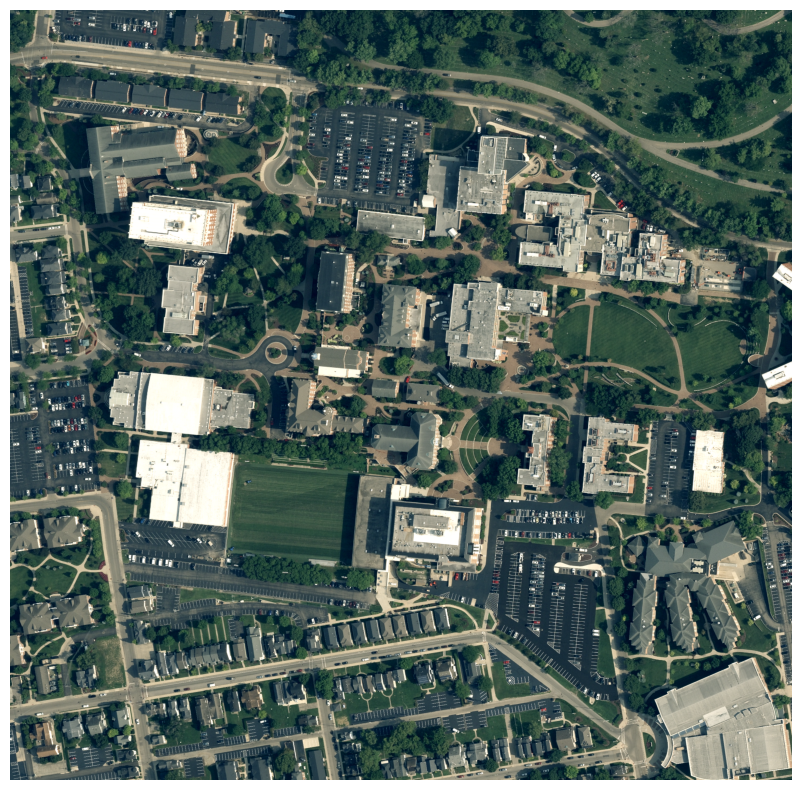

In [7]:
geoai.view_image(raster_path, figsize=(18, 10))

<Axes: >

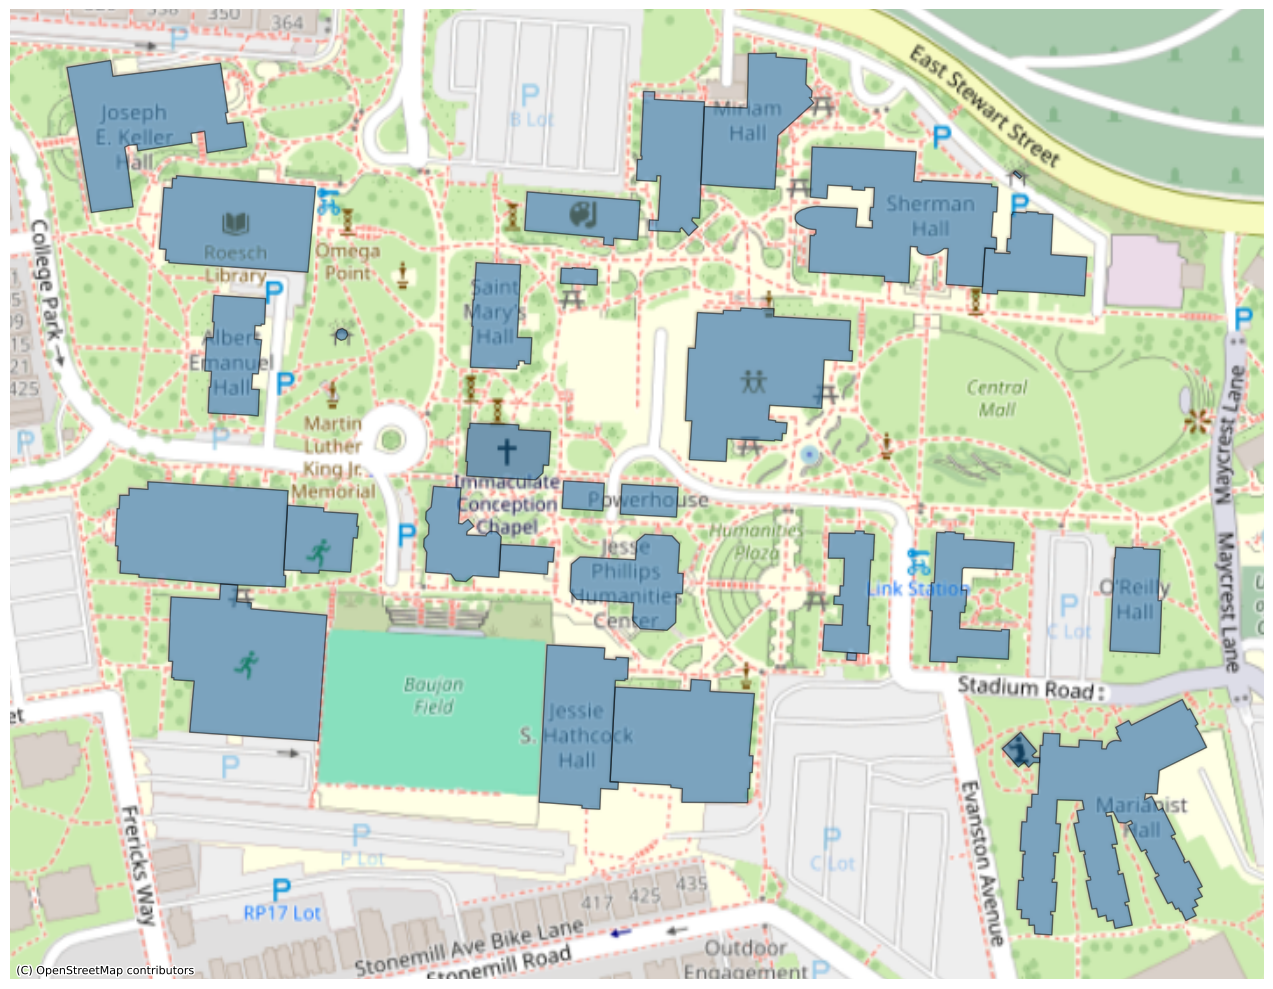

In [8]:
geoai.view_vector(vector_path, basemap=True, alpha=0.5, figsize=(18, 10))

In [9]:
geoai.view_vector_interactive(vector_path)

## Convert vector to raster

In [10]:
output_path = vector_path.replace(".geojson", ".tif")
geoai.vector_to_raster(vector_path, output_path, reference_raster=raster_path)

Reprojecting vector data from EPSG:4326 to EPSG:26917
Rasterized data saved to buildings.tif


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

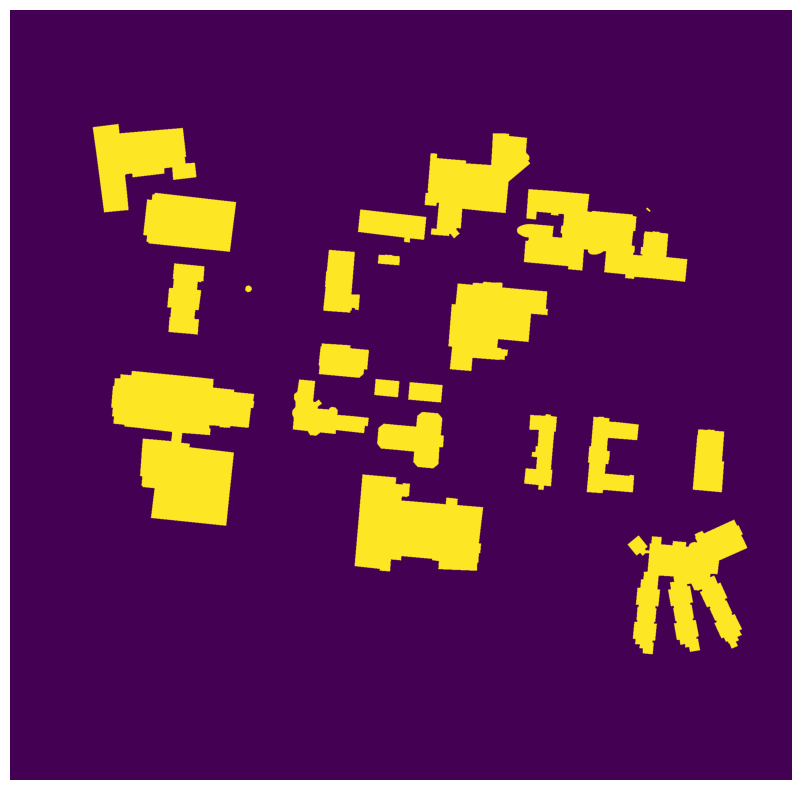

In [11]:
geoai.view_image(output_path, figsize=(18, 10))

## Generate image chips

In [12]:
tiles = geoai.export_geotiff_tiles(
    in_raster=raster_path,
    out_folder="output",
    in_class_data=vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
    create_overview=True,
    quiet=True,
)

Generated: 64, With features: 56: 100%|██████████| 64/64 [00:02<00:00, 27.69it/s]


Overview image saved to output/overview.png


## Preview image chips

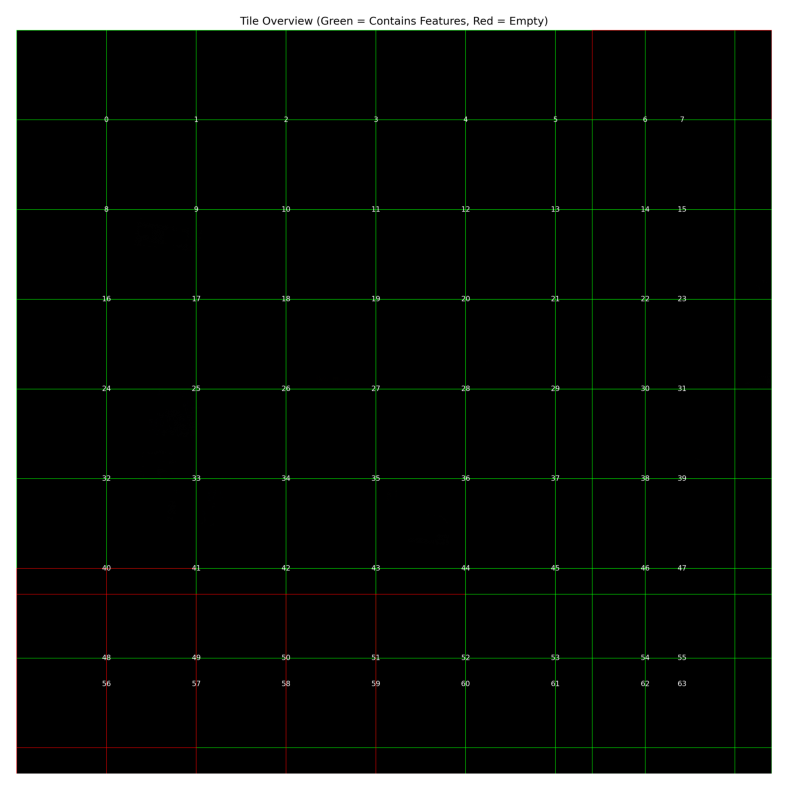

In [13]:
geoai.view_image("output/overview.png", figsize=(18, 10))

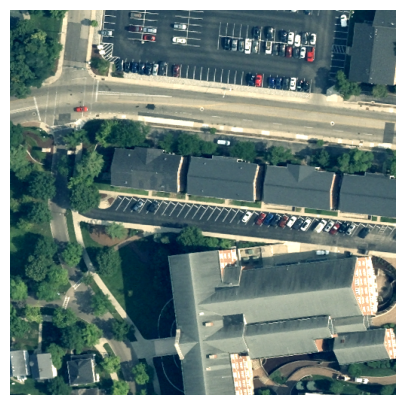

In [14]:
geoai.view_image("output/images/tile_000000.tif")

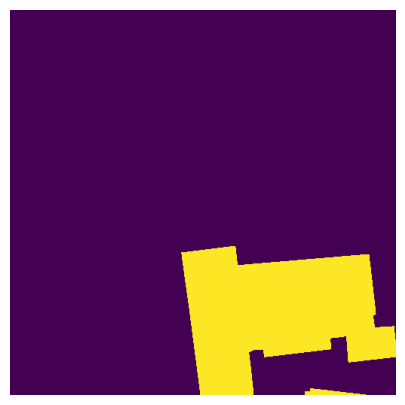

In [15]:
geoai.view_image("output/labels/tile_000000.tif")

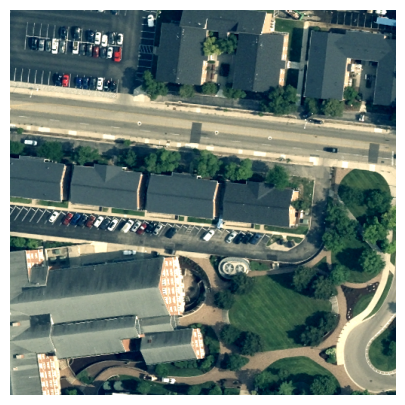

In [16]:
geoai.view_image("output/images/tile_000001.tif")

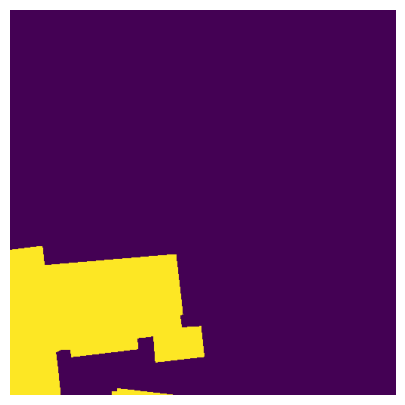

In [17]:
geoai.view_image("output/labels/tile_000001.tif")